In [25]:

import h5py
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import yaml
from TraceSimulator import TraceSimulator

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml')
ts = TraceSimulator(config)



In [26]:
def plot_traces(traces, fs=3_906_250, offset_step=70, title="Simulated Traceset", ax=None, show=True):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    if ax is None:
        _, ax = plt.subplots(figsize=(18, 12))

    for i in range(num_channels):
        color = 'orange' if i > 19 else 'tab:blue'
        ax.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    ax.text(0.01, 1.09, "DELight", transform=ax.transAxes, ha='left', va='top', fontsize=23, fontweight='bold', clip_on=False)
    ax.text(0.99, 1.09, "Simulation", transform=ax.transAxes, ha='right', va='top', fontsize=23, fontweight='bold', clip_on=False)

    ax.set_xlabel("Time [ms]", fontsize=16, fontweight='bold')
    ax.set_ylabel("ADC counts", fontsize=16, fontweight='bold')
    ax.set_title(title, fontsize=28, fontweight='bold')
    ax.set_xlim(0, time_ms[-1])
    ax.set_ylim(-10, offset_step * (num_channels + 1))
    ax.set_yticks([])

    if show:
        plt.tight_layout()
        plt.show()

    return ax


[-90.26126208] [78.19945266] [-1694.28896359]


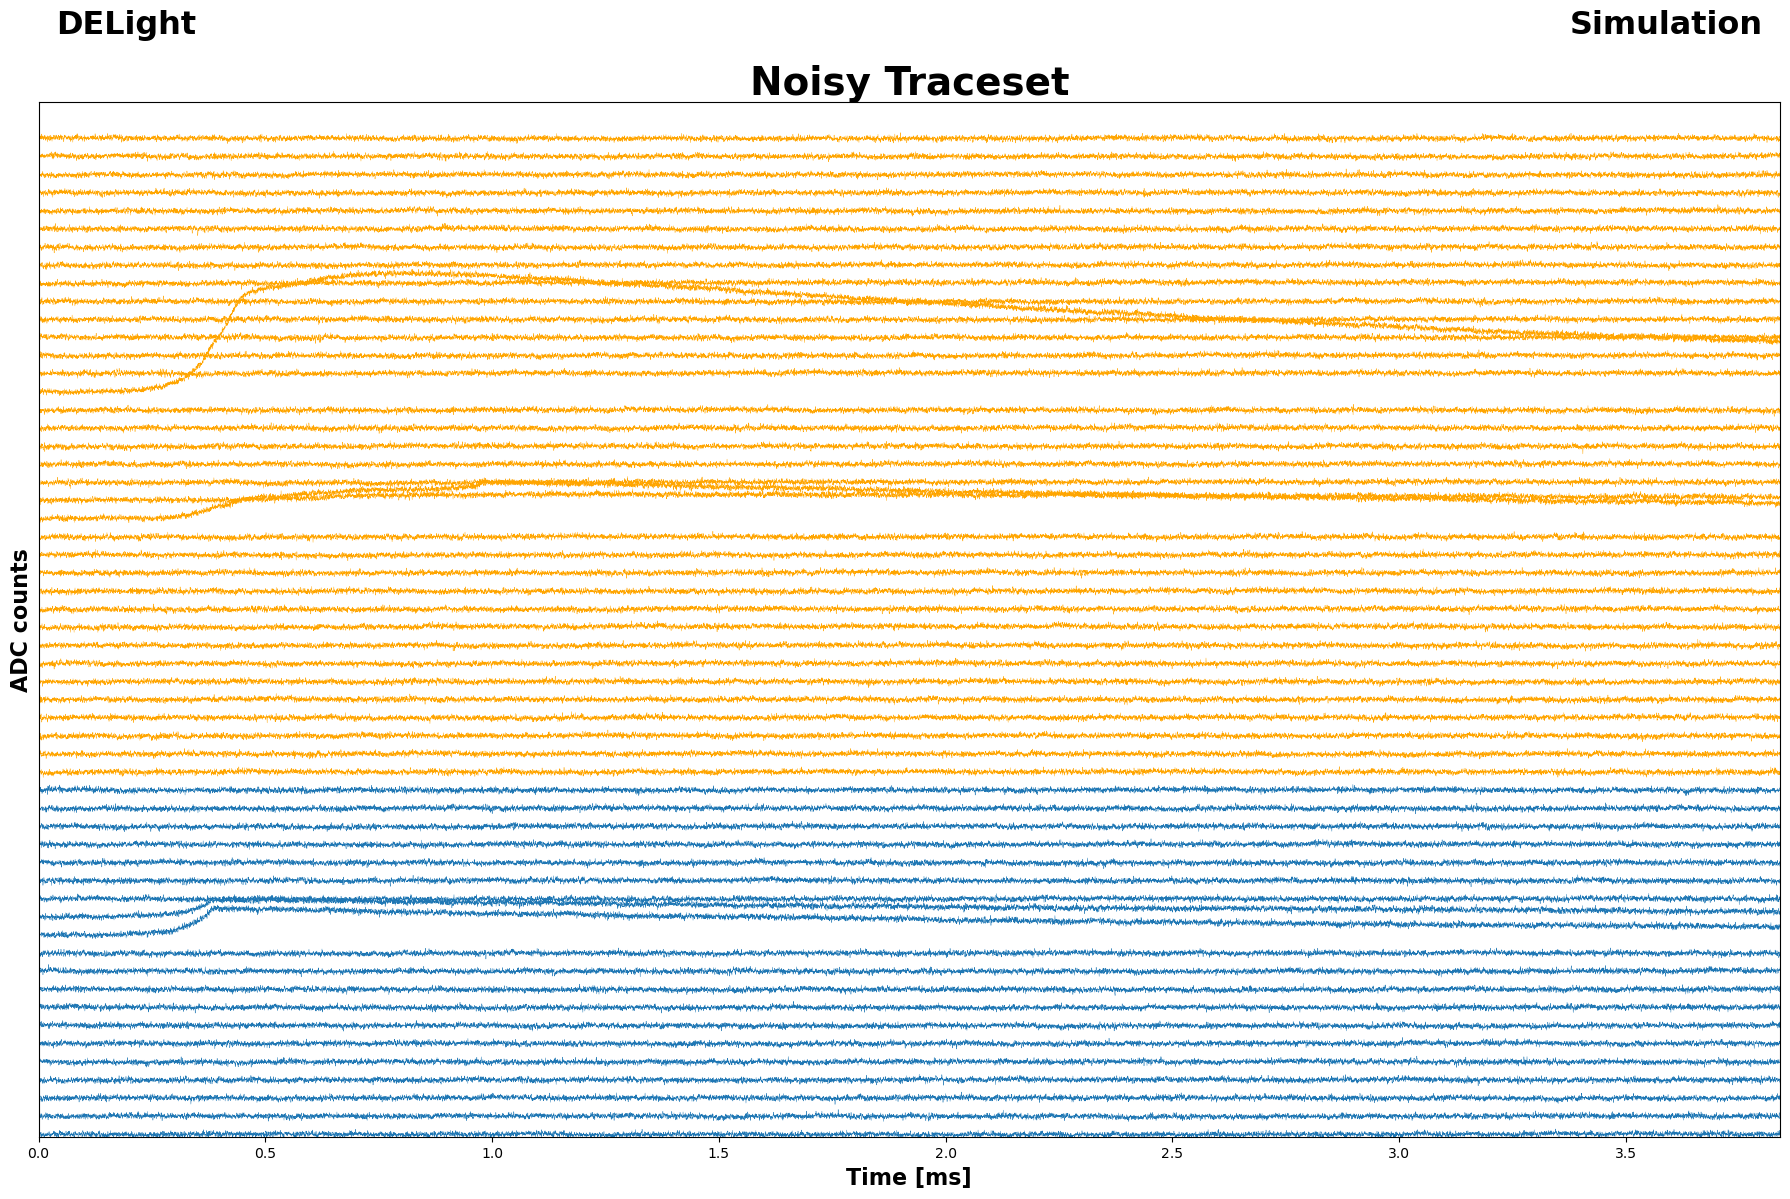

<Axes: title={'center': 'Noisy Traceset'}, xlabel='Time [ms]', ylabel='ADC counts'>

In [35]:
trace,(x, y, z) = ts.generate(800, type_recoil='NR') # generate a 20 keV ER from a random position in the volume
print(x, y, z)
# Noisy traceset only
plot_traces(trace, title='Noisy Traceset')


/tmp/ipykernel_3942105/1015157379.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=3.5)


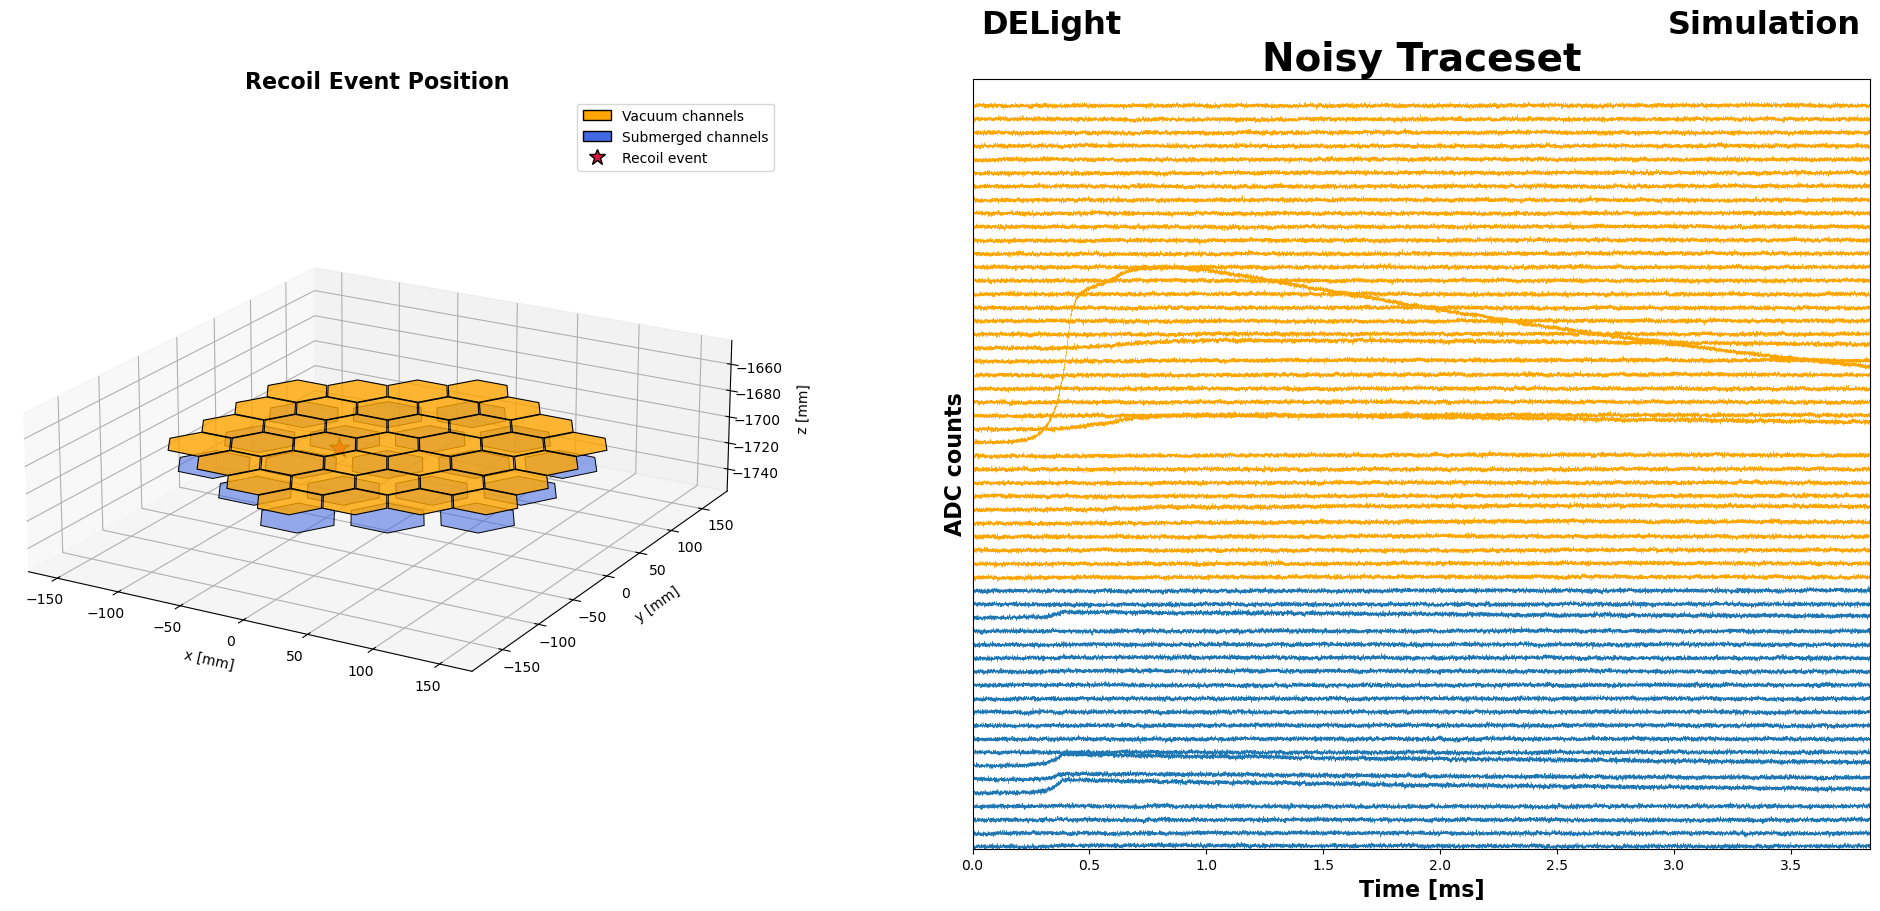

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon, Patch
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --------------------
# Config
# --------------------
sensor_z        = -1692
hex_radius_sel  = 49.5 / 2.0      # base radius for selected (Vacuum)
other_scale     = 1.15            # scale factor to make unselected (Submerged) larger
hex_radius_oth  = hex_radius_sel * other_scale
orientation     = np.pi / 6       # match 2D
zoom_pad        = 60.0            # mm

# Colors
color_sel = "orange"              # Vacuum channels (selected)
color_oth = "royalblue"           # Submerged channels (unselected)
recoil_color = "crimson"

positions = ts.LAMCAL_position  # shape (N, 3)

# Extract x, y, z
x_pos = positions[:, 0]
y_pos = positions[:, 1]
z_pos = positions[:, 2]

# Groups
mask_sel = (z_pos == sensor_z)
selected = positions[mask_sel]
others   = positions[~mask_sel]

# Recoil event position from simulator output (robust to scalar/array inputs)
recoil_x = float(np.atleast_1d(x)[0])
recoil_y = float(np.atleast_1d(y)[0])
recoil_z = float(np.atleast_1d(z)[0])

def hexagon_vertices_like_2d(xc, yc, zc, radius):
    """Match 2D RegularPolygon orientation/size, then lift to z=zc."""
    rp = RegularPolygon((xc, yc), numVertices=6, radius=radius, orientation=orientation)
    verts2d = rp.get_verts()
    return [(vx, vy, zc) for vx, vy in verts2d]

# --------------------
# Two-panel figure
# --------------------
fig = plt.figure(figsize=(24, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.65], wspace=0.28)
ax_geo = fig.add_subplot(gs[0, 0], projection="3d")
ax_trace = fig.add_subplot(gs[0, 1])

# Left: geometry + recoil position
for xi, yi, zi in selected:
    verts3d = hexagon_vertices_like_2d(xi, yi, zi, hex_radius_sel)
    ax_geo.add_collection3d(Poly3DCollection([verts3d], facecolor=color_sel, edgecolor="k", alpha=0.8, linewidths=0.8))

for xi, yi, zi in others:
    verts3d = hexagon_vertices_like_2d(xi, yi, zi, hex_radius_oth)
    ax_geo.add_collection3d(Poly3DCollection([verts3d], facecolor=color_oth, edgecolor="k", alpha=0.55, linewidths=0.7))

ax_geo.scatter(recoil_x, recoil_y, recoil_z, s=220, c=recoil_color, marker='*', edgecolors='k', linewidths=0.8)

ax_geo.set_xlabel("x [mm]", labelpad=10)
ax_geo.set_ylabel("y [mm]", labelpad=10)
ax_geo.set_zlabel("z [mm]", labelpad=10)
ax_geo.set_title("Recoil Event Position", fontsize=16, fontweight='bold')

if selected.size > 0:
    ax_geo.set_xlim(selected[:, 0].min() - zoom_pad, selected[:, 0].max() + zoom_pad)
    ax_geo.set_ylim(selected[:, 1].min() - zoom_pad, selected[:, 1].max() + zoom_pad)
else:
    ax_geo.set_xlim(x_pos.min() - zoom_pad, x_pos.max() + zoom_pad)
    ax_geo.set_ylim(y_pos.min() - zoom_pad, y_pos.max() + zoom_pad)

z_pad = 50.0
ax_geo.set_zlim(z_pos.min() - z_pad, z_pos.max() + z_pad)
ax_geo.view_init(elev=20, azim=-60)

xr, yr, zr = ax_geo.get_xlim(), ax_geo.get_ylim(), ax_geo.get_zlim()
ax_geo.set_box_aspect((xr[1] - xr[0], yr[1] - yr[0], zr[1] - zr[0]))

geo_legend = [
    Patch(facecolor=color_sel, edgecolor='k', label='Vacuum channels'),
    Patch(facecolor=color_oth, edgecolor='k', label='Submerged channels'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor=recoil_color, markeredgecolor='k', markersize=12, label='Recoil event')
]
ax_geo.legend(handles=geo_legend, loc='upper right', bbox_to_anchor=(1.05, 1.0))

# Right: noisy traceset
plot_traces(trace, title="Noisy Traceset", ax=ax_trace, show=False)

plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=3.5)
plt.show()


Correlation source: /ceph/dwong/work/threshold/pink_run1/noise_1.8/traces_energy_46.h5
Used traces shape: (50, 56, 2048) (events, channels, samples_after_stride)
cross_corr shape: (56, 56)


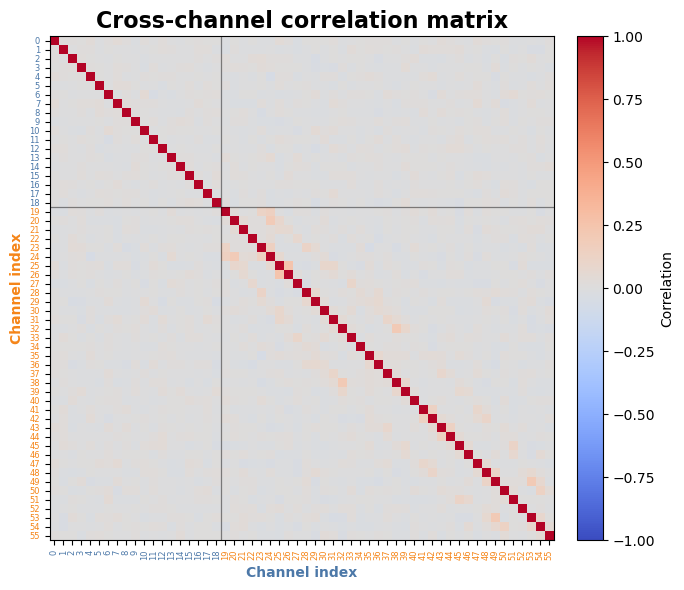

In [31]:
# Real 56-channel dataset source (HDF5)
DATA_FILE = Path('/ceph/dwong/work/threshold/pink_run1/noise_1.8/traces_energy_46.h5')
N_CHANNELS = 56
N_EVENTS = 50         # up to first 50 events from this file
SAMPLE_STRIDE = 8     # downsample in time for faster correlation
GROUP_SPLIT = 19      # first 19 submerged, remaining 37 vacuum

if not DATA_FILE.exists():
    raise FileNotFoundError(f'Dataset file not found: {DATA_FILE}')

with h5py.File(DATA_FILE, 'r') as f:
    if 'traces_MMC' in f:
        dset = f['traces_MMC']
    elif 'traces' in f:
        dset = f['traces']
    else:
        raise KeyError('No supported trace dataset found (expected "traces" or "traces_MMC").')

    n_events_avail, n_channels_avail, _ = dset.shape
    n_events_use = min(N_EVENTS, n_events_avail)
    n_channels_use = min(N_CHANNELS, n_channels_avail)

    # Read real traces from disk, then flatten (channel, event*time)
    traces_real = np.asarray(
        dset[:n_events_use, :n_channels_use, ::SAMPLE_STRIDE],
        dtype=np.float32,
    )

if traces_real.shape[1] != N_CHANNELS:
    raise ValueError(f'Expected {N_CHANNELS} channels, got {traces_real.shape[1]} from {DATA_FILE}')

flat = traces_real.transpose(1, 0, 2).reshape(N_CHANNELS, -1)
cross_corr = np.corrcoef(flat)

print('Correlation source:', DATA_FILE)
print('Used traces shape:', traces_real.shape, '(events, channels, samples_after_stride)')
print('cross_corr shape:', cross_corr.shape)

fig, ax = plt.subplots(1, 1, figsize=(7.0, 6.0))
im = ax.imshow(
    cross_corr,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    interpolation='nearest',
)

split = GROUP_SPLIT
ax.axvline(split - 0.5, color='k', linewidth=0.9, alpha=0.45)
ax.axhline(split - 0.5, color='k', linewidth=0.9, alpha=0.45)

# Put blue/orange encoding on axes instead of background regions.
blue = '#4C78A8'
orange = '#F58518'

ax.set_title('Cross-channel correlation matrix', fontsize=16, fontweight='bold')
ax.set_xlabel('Channel index', color=blue, fontweight='bold')
ax.set_ylabel('Channel index', color=orange, fontweight='bold')

# Tick labels colored by channel group: submerged (blue), vacuum (orange).
xt = np.arange(N_CHANNELS)
yt = np.arange(N_CHANNELS)
ax.set_xticks(xt)
ax.set_yticks(yt)
ax.set_xticklabels(xt, fontsize=6, rotation=90)
ax.set_yticklabels(yt, fontsize=6)

for i, lbl in enumerate(ax.get_xticklabels()):
    lbl.set_color(blue if i < split else orange)
for i, lbl in enumerate(ax.get_yticklabels()):
    lbl.set_color(blue if i < split else orange)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
plt.tight_layout()
plt.show()
